## how does real GPT2 look like?

In [2]:
from transformers import GPT2LMHeadModel

/home/mzums/miniconda3/envs/fakewiki/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2")  # 124M
sd_hf = model_hf.state_dict()

# tensors
for k, v in sd_hf.items():
    print(k, v.shape)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 10560.68it/s]


transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

^ *GPT2 has 50257 tokens*  
768 dimentional embedding  
1024 max sequence length

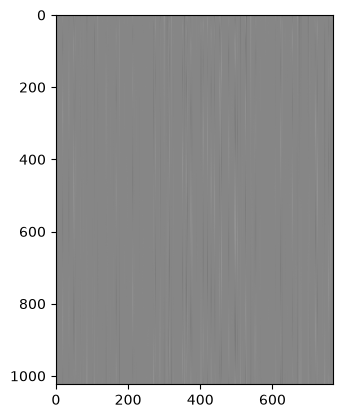

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(sd_hf["transformer.wpe.weight"], cmap="gray")

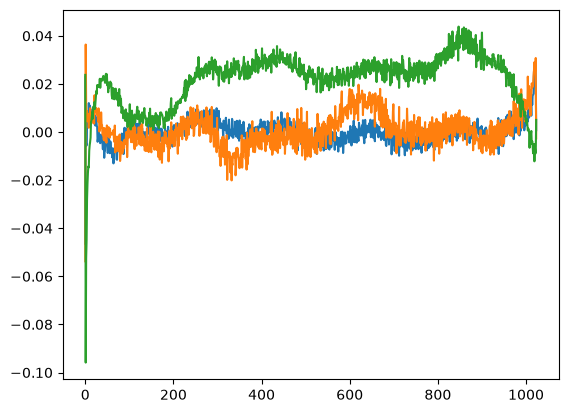

In [9]:
plt.plot(sd_hf["transformer.wpe.weight"][:, 150])
plt.plot(sd_hf["transformer.wpe.weight"][:, 200])
plt.plot(sd_hf["transformer.wpe.weight"][:, 250])

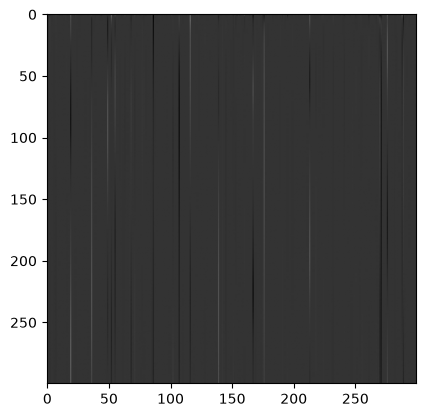

In [10]:
plt.imshow(sd_hf["transformer.wpe.weight"][:300,:300], cmap="gray")

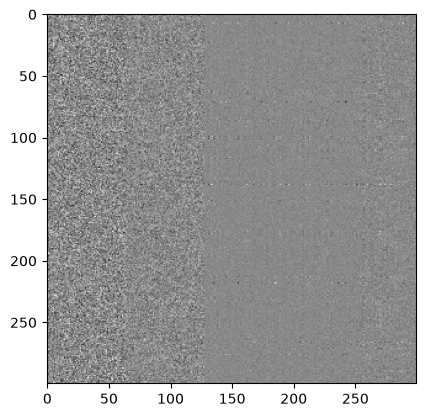

In [11]:
plt.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"][:300,:300], cmap="gray")

### sampling

In [13]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator("Hello, I'm a language model", max_length=30, num_return_sequences=5)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 11512.56it/s]
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'Hello, I\'m a language model for you" —Miles Teller (@milesteller) October 13, 2015\n\nI guess I\'ll just have to watch out for this.\n\nUPDATE: This post has been updated with comments from the author.'},
 {'generated_text': "Hello, I'm a language model. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the wo

In [14]:
generator("Machine learning (ML) is a field of study in artificial intelligence ", max_length=30, num_return_sequences=5) 

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'Machine learning (ML) is a field of study in artificial intelligence \xa0for which there are many groups working on the same problem. ML is a natural language learning algorithm that is relatively straightforward to use. ML is also the study of problems that are difficult to solve with finite-dimensional ML algorithms. ML algorithms can be thought of as a kind of learning machine, but they are very different from machine learning. ML is an algorithm that has an easy description of its data (that is, it is only partially able to read and understand some data, and that is not the same as the machine learning problem or problem solving problem that the machine learning problem solves). It is a type of machine learning algorithm that has the following characteristics: It can learn to solve most problems by one step (for example, if one character in the data is in the wrong place, then it will not be able to read the correct character).\nIt can learn to solve most probl